In [45]:
from web3 import Web3, HTTPProvider
import json
import rlp
from eth_typing import HexStr
from eth_utils import to_bytes
import math
import matplotlib.pyplot as plt
import pandas as pd
import json
import numpy as np
from scipy.stats import norm
import seaborn as sns
plt.rcParams["savefig.dpi"] = 300

# Data

In [26]:
def get_input_data(n_pv_remove):

    indexes = pd.read_excel("./data/EC_EV_dataset.xlsx",sheet_name ="Indexes")
    indexes.set_index("Player ID",inplace=True)

    # loads
    loads = pd.read_excel("./data/EC_EV_dataset.xlsx",sheet_name ="Load")
    loads = loads.add_prefix("load")
    loads = loads.rename(columns={"loadTime": "Time"})
    loads = pd.wide_to_long(loads,stubnames="load",i= "Time",j='ID')

    # ev loads
    ev_loads =  pd.read_excel("./data/EC_EV_dataset.xlsx",sheet_name ="EV1 Load")
    ev_loads = ev_loads.add_prefix("ev_load")
    ev_loads = ev_loads.rename(columns={"ev_loadTime": "Time"})
    ev_loads = pd.wide_to_long(ev_loads,stubnames="ev_load",i="Time",j="ID")

    # pv gen
    pv = pd.read_excel("./data/EC_EV_dataset.xlsx",sheet_name="PV")
    pv = pv.add_prefix("pv_gen")
    pv = pv.rename(columns={"pv_genTime": "Time"})
    # remove generation profile of 50 randomly selected households
    pv=pv.set_index("Time")
    pv.loc[:,pv.loc[:,(pv>0).any()].sample(n=n_pv_remove,axis=1,random_state=0).columns] = 0
    #check if exactly 150 generation profiles remain
    print(len(pv.loc[:,(pv>0).any()].columns))
    pv=pv.reset_index()
    pv = pd.wide_to_long(pv,stubnames="pv_gen",i= "Time",j='ID')


    # k_lower
    sell_price = pd.read_excel("./data/EC_EV_dataset.xlsx",sheet_name="Sell Price")
    sell_price = sell_price.add_prefix("sell_price")
    sell_price = sell_price.rename(columns={"sell_priceTime": "Time"})
    sell_price = pd.wide_to_long(sell_price,stubnames="sell_price",i= "Time",j='ID')
    sell_price["sell_price"]=sell_price["sell_price"]

    #k_upper
    buy_price = pd.read_excel("./data/EC_EV_dataset.xlsx",sheet_name="Buy Price")
    buy_price = buy_price.add_prefix("buy_price")
    buy_price = buy_price.rename(columns={"buy_priceTime": "Time"})
    buy_price = pd.wide_to_long(buy_price,stubnames="buy_price",i= "Time",j='ID')
    buy_price["buy_price"]=buy_price["buy_price"]


    # merge datasets
    times = pd.date_range("00:00","23:45",freq="15min")
    data = loads.merge(right= pv,left_index=True,right_index=True).merge(right = ev_loads,left_index=True,right_index=True).merge(right=buy_price,right_index=True,left_index=True).merge(right=sell_price,right_index=True,left_index=True)
    data["clock"] = [times[i-1].time() for i in data.index.get_level_values(0)]
    data["surplus"]= (data["pv_gen"]-data["load"]).apply(lambda x: max(x,0))
    data["demand"]= (data["load"]-data["pv_gen"]).apply(lambda x: max(x,0))

    #  add synthetic bidding data
    #bidding_data = pd.read_csv("./data/players_L1.csv")
    #sell_offers = bidding_data[:24]["P_n"].copy()
    #buy_offers = bidding_data[24:]["P_n"].copy()
    # fit norm. dists for buyer and seller offers
    data["max_surplus"]=data["surplus"].groupby("ID").transform("max")
    ## ask price for sellers. The higher the surplus, the lower the ask price.
    data["bid_price_sellers"]=data.apply(lambda row: max(0.045,norm.rvs((row.buy_price+row.sell_price)*1/2 *(1.5-row.surplus/row.max_surplus),0.03)) if row.surplus > 0 else None,axis=1)
    ## bid price for buyers. Not correlated with demand
    data["bid_price_buyers"] = data.apply(lambda row: norm.rvs((row.buy_price+row.sell_price)*2/3,0.01) if row.demand > 0 else None,axis = 1)
    return data


# save input datasets

## 70% households with solar panels
data70 = get_input_data(n_pv_remove=25)
# remove rounds without energy surplus to save time during simulation
data70 = data70.groupby("Time").filter(lambda x: x["surplus"].sum()>0)
#data70.to_excel("./data/input_data_70_pv.xlsx")

## 50% households with solar panels
data50= get_input_data(n_pv_remove=75)
data50= data50.groupby("Time").filter(lambda x: x["surplus"].sum()>0)
#data50.to_excel("./data/input_data_50_pv.xlsx")

## 30% households with solar panels
data30 = get_input_data(n_pv_remove=125)
data30 = data30.groupby("Time").filter(lambda x: x["surplus"].sum()>0)
#data30.to_excel("./data/input_data_30_pv.xlsx")





175
125
75


In [2]:
print((data30["surplus"].sum(),data50["surplus"].sum(),data70["surplus"].sum()))

NameError: name 'data30' is not defined

# Bidding Vis

C:\Users\hmart\AppData\Local\Temp\ipykernel_20976\2860650399.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bid_vis.rename({"bid_price_buyers":"Buyers Bids","bid_price_sellers":"Sellers bids"},inplace=True,axis=1)


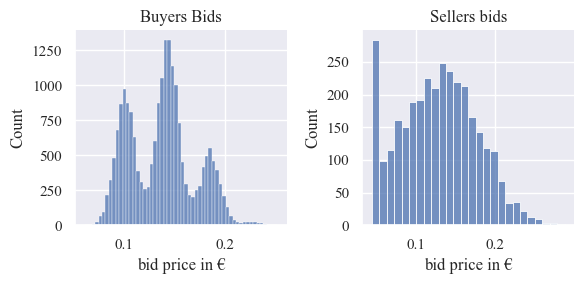

In [12]:
sns.set_theme(style="darkgrid")
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})
sns.set_theme(rc={'font.family':'serif', 'font.serif':'Times New Roman'},style="darkgrid")
bid_vis = data70[["bid_price_buyers","bid_price_sellers"]]
bid_vis.rename({"bid_price_buyers":"Buyers Bids","bid_price_sellers":"Sellers bids"},inplace=True,axis=1)
bid_vis = bid_vis.melt(value_vars=["Buyers Bids","Sellers bids"])
g = sns.FacetGrid(bid_vis,col="variable",sharex=False,sharey=False)
g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.histplot, x="value")
g.set_xlabels("bid price in €")
#ns.histplot(bid_vis,x="value",hue="variable",bins=50)
#sns.histplot(data,x="bid_price_sellers",bins=50)
g.savefig("./Images/Bidding_Data.png")

## Testing Pricing Function

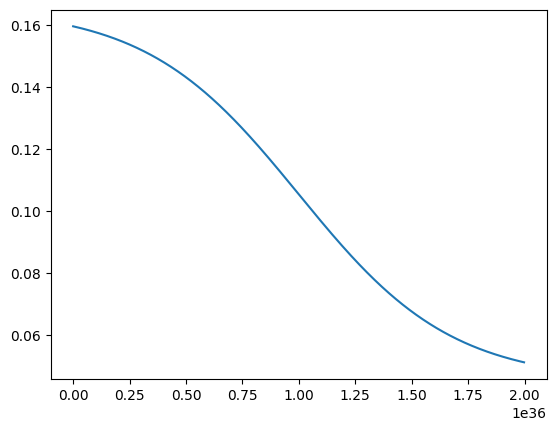

In [8]:
# Testing pricing function
prices = []
rations = []
k_upper = data['buy_price'].agg('mean')
k_lower = data['sell_price'].agg('mean')
AMMContract.functions.set_k_lower(int(k_lower*1e18)).transact({'from':admin})
AMMContract.functions.set_k_upper(int(k_upper*1e18)).transact({'from':admin})
AMMContract.functions.set_steepness(int(2.95*1e18)).transact({'from':admin})
AMMContract.functions.set_midpoint(int(1*1e18)).transact({'from':admin})
for i in range(0,1000):
    price = AMMContract.functions.get_price(int(500*1e18),int(i*1e18)).call()
    prices.append(price/1e18)
    rations.append(i*1e18/500*1e18)

plt.plot(rations,prices)

# Simulations

## Full run

In [46]:
def simualte(data,params):
    ############ SETUP ################

    #connect to Blockchain
    w3 = Web3(Web3.HTTPProvider('http://127.0.0.1:8545',request_kwargs={'timeout': 600}))
    print(w3.is_connected())
    
    # get active wallets
    accounts = w3.eth.accounts
    
    #get token and AMMBA smart contracts ABI interfaces
    AbiPath = './build/contracts/'
    AMMabi = json.load(open(AbiPath + 'AMMBA.json'))['abi']
    Energyabi = json.load(open(AbiPath + 'EnergyToken.json'))['abi']
    Moneyabi = json.load(open(AbiPath + 'MoneyToken.json'))['abi']
   
    # instatiate tokens and contract
    MoneyToken_address = Web3.to_checksum_address("0xe78A0F7E598Cc8b0Bb87894B0F60dD2a88d6a8Ab")
    EnergyToken_address = Web3.to_checksum_address("0x5b1869D9A4C187F2EAa108f3062412ecf0526b24")
    Amm_address = Web3.to_checksum_address("0xCfEB869F69431e42cdB54A4F4f105C19C080A601")
    AMMContract = w3.eth.contract(address=Amm_address,abi=AMMabi)
    MoneyContract = w3.eth.contract(address=MoneyToken_address,abi=Moneyabi)
    EnergyContract = w3.eth.contract(address=EnergyToken_address,abi=Energyabi)
    
    # set admin wallet
    admin = Web3.to_checksum_address(w3.eth.accounts[0])
    
    ########## START SIMULATION #############
    # copy data
    out=data.copy()
    
    # set pricing function parameters
    midpoint,steepness = params
    AMMContract.functions.set_steepness(int(steepness*1e18)).transact({'from':admin})
    AMMContract.functions.set_midpoint(int(midpoint*1e18)).transact({'from':admin})

    # iterate over time steps
    for i in data.index.get_level_values(0).unique():
        #set k_upper and k_lower
        k_upper = out.xs(i)['buy_price'].mean()
        k_lower = out.xs(i)['sell_price'].mean()
        AMMContract.functions.set_k_lower(int(k_lower*1e18)).transact({'from':admin})
        AMMContract.functions.set_k_upper(int(k_upper*1e18)).transact({'from':admin})

        # iterate over 250 players
        for j in range (1,251):
            demand = out.loc[(i,j),"demand"]
            surplus = out.loc[(i,j),"surplus"]
            money_deposit = out.loc[(i,j),"demand"]*out.loc[(i,j),"bid_price_buyers"]
            address = accounts[j]
            #if member needs energy
            print(str(i) + " " + str(j) + " @lower " + str(k_lower) + " @upper "+ str(k_upper))
            if (demand > 0):
                # Fund account
                Funds = int(money_deposit*1e18)
                MoneyContract.functions.transfer(address,Funds).transact({'from':admin})
                # approve
                MoneyContract.functions.approve(Amm_address,Funds).transact({'from':address})
                # swap
                AMMContract.functions.swap(MoneyToken_address,Funds).transact({'from':address})
            else: 
                # Fund Energy
                Surplus = int(surplus*1e18)
                EnergyContract.functions.transfer(address,Surplus).transact({'from':admin})
                # approve
                EnergyContract.functions.approve(Amm_address,Surplus).transact({'from':address})
                # swap
                AMMContract.functions.swap(EnergyToken_address,Surplus).transact({'from':address})
        clear_hash = AMMContract.functions.clear().transact({'from': admin})

    ######### GET LOGS ############

    for i in range(0,len(data.index.get_level_values(0).unique())):
        for j in range(0,250):
            info = AMMContract.functions.get_member_info(i,accounts[j+1]).call()
            #print(str(i)+" "+str(j))
            out.loc[(i+34,j+1),"money_in"] = info[0]/1e18
            out.loc[(i+34,j+1),"energy_in"] = info[1]/1e18
            out.loc[(i+34,j+1),"money_out"]=info[3]/1e18
            out.loc[(i+34,j+1),"energy_out"]=info[4]/1e18
            out.loc[(i+34,j+1),"price"]= AMMContract.functions.get_price(i).call()/1e18

    return out

In [35]:
params_low = (np.float64(1.252280038881754),np.float64(0.9025061693804254))
params_mid= (np.float64(2.7366558386807447),np.float64(0.4127245127514755))
params_high = (np.float64(5.953998393410741),np.float64(0.19187317821232616))

In [36]:
#### Scenario low
data30 = pd.read_excel("./data/input_data_30_pv.xlsx")
data30.set_index(["Time","ID"],inplace=True)
result_data = simualte(data30,params_low)
result_data.to_excel("./simulation_results/AMMBA_result_data_30_pv.xlsx")


True
34 1 @lower 0.045 @upper 0.170652
34 2 @lower 0.045 @upper 0.170652
34 3 @lower 0.045 @upper 0.170652
34 4 @lower 0.045 @upper 0.170652
34 5 @lower 0.045 @upper 0.170652
34 6 @lower 0.045 @upper 0.170652
34 7 @lower 0.045 @upper 0.170652
34 8 @lower 0.045 @upper 0.170652
34 9 @lower 0.045 @upper 0.170652
34 10 @lower 0.045 @upper 0.170652
34 11 @lower 0.045 @upper 0.170652
34 12 @lower 0.045 @upper 0.170652
34 13 @lower 0.045 @upper 0.170652
34 14 @lower 0.045 @upper 0.170652
34 15 @lower 0.045 @upper 0.170652
34 16 @lower 0.045 @upper 0.170652
34 17 @lower 0.045 @upper 0.170652
34 18 @lower 0.045 @upper 0.170652
34 19 @lower 0.045 @upper 0.170652
34 20 @lower 0.045 @upper 0.170652
34 21 @lower 0.045 @upper 0.170652
34 22 @lower 0.045 @upper 0.170652
34 23 @lower 0.045 @upper 0.170652
34 24 @lower 0.045 @upper 0.170652
34 25 @lower 0.045 @upper 0.170652
34 26 @lower 0.045 @upper 0.170652
34 27 @lower 0.045 @upper 0.170652
34 28 @lower 0.045 @upper 0.170652
34 29 @lower 0.045 @uppe

In [44]:
#### Scenario medium
data50 = pd.read_excel("./data/input_data_50_pv.xlsx")
data50.set_index(["Time","ID"],inplace=True)
result_data = simualte(data50,params_mid)
result_data.to_excel("./simulation_results/AMMBA_result_data_50_pv.xlsx")

True
34 1 @lower 0.045 @upper 0.170652
34 2 @lower 0.045 @upper 0.170652
34 3 @lower 0.045 @upper 0.170652
34 4 @lower 0.045 @upper 0.170652
34 5 @lower 0.045 @upper 0.170652
34 6 @lower 0.045 @upper 0.170652
34 7 @lower 0.045 @upper 0.170652
34 8 @lower 0.045 @upper 0.170652
34 9 @lower 0.045 @upper 0.170652
34 10 @lower 0.045 @upper 0.170652
34 11 @lower 0.045 @upper 0.170652
34 12 @lower 0.045 @upper 0.170652
34 13 @lower 0.045 @upper 0.170652
34 14 @lower 0.045 @upper 0.170652
34 15 @lower 0.045 @upper 0.170652
34 16 @lower 0.045 @upper 0.170652
34 17 @lower 0.045 @upper 0.170652
34 18 @lower 0.045 @upper 0.170652
34 19 @lower 0.045 @upper 0.170652
34 20 @lower 0.045 @upper 0.170652
34 21 @lower 0.045 @upper 0.170652
34 22 @lower 0.045 @upper 0.170652
34 23 @lower 0.045 @upper 0.170652
34 24 @lower 0.045 @upper 0.170652
34 25 @lower 0.045 @upper 0.170652
34 26 @lower 0.045 @upper 0.170652
34 27 @lower 0.045 @upper 0.170652
34 28 @lower 0.045 @upper 0.170652
34 29 @lower 0.045 @uppe

In [47]:
#### Scenario high
data70 = pd.read_excel("./data/input_data_70_pv.xlsx")
data70.set_index(["Time","ID"],inplace=True)
result_data = simualte(data70,params_high)
result_data.to_excel("./simulation_results/AMMBA_result_data_70_pv.xlsx")

True
34 1 @lower 0.045 @upper 0.170652
34 2 @lower 0.045 @upper 0.170652
34 3 @lower 0.045 @upper 0.170652
34 4 @lower 0.045 @upper 0.170652
34 5 @lower 0.045 @upper 0.170652
34 6 @lower 0.045 @upper 0.170652
34 7 @lower 0.045 @upper 0.170652
34 8 @lower 0.045 @upper 0.170652
34 9 @lower 0.045 @upper 0.170652
34 10 @lower 0.045 @upper 0.170652
34 11 @lower 0.045 @upper 0.170652
34 12 @lower 0.045 @upper 0.170652
34 13 @lower 0.045 @upper 0.170652
34 14 @lower 0.045 @upper 0.170652
34 15 @lower 0.045 @upper 0.170652
34 16 @lower 0.045 @upper 0.170652
34 17 @lower 0.045 @upper 0.170652
34 18 @lower 0.045 @upper 0.170652
34 19 @lower 0.045 @upper 0.170652
34 20 @lower 0.045 @upper 0.170652
34 21 @lower 0.045 @upper 0.170652
34 22 @lower 0.045 @upper 0.170652
34 23 @lower 0.045 @upper 0.170652
34 24 @lower 0.045 @upper 0.170652
34 25 @lower 0.045 @upper 0.170652
34 26 @lower 0.045 @upper 0.170652
34 27 @lower 0.045 @upper 0.170652
34 28 @lower 0.045 @upper 0.170652
34 29 @lower 0.045 @uppe

## Single run

In [83]:
k_upper = data['buy_price'].agg('mean')
k_lower = data['sell_price'].agg('mean')
i=53
# set upper and lower price limit
results = {}
k_upper = data.xs(i)['buy_price'].mean()
k_lower = data.xs(i)['sell_price'].mean()
AMMContract.functions.set_k_lower(int(k_lower*1e18)).transact({'from':admin})
AMMContract.functions.set_k_upper(int(k_upper*1e18)).transact({'from':admin})
for j in range (1,251):
    demand = data.loc[(i,j),"demand"]
    surplus = data.loc[(i,j),"surplus"]
    energy_value = data.loc[(i,j),"cost of demand"]
    address = accounts[j]
    #if member needs energy
    print(str(i) + " " + str(j) + " @lower " + str(k_lower) + " @upper "+ str(k_upper))
    if (demand > 0):
        # Fund account
        Funds = int(energy_value*1e18)
        MoneyContract.functions.transfer(address,Funds).transact({'from':admin})
        # approve
        MoneyContract.functions.approve(Amm_address,Funds).transact({'from':address})
        # swap
        AMMContract.functions.swap(MoneyToken_address,Funds).transact({'from':address})
    else: 
        # Fund Energy
        Surplus = int(surplus*1e18)
        print(surplus)
        EnergyContract.functions.transfer(address,Surplus).transact({'from':admin})
        # approve
        EnergyContract.functions.approve(Amm_address,Surplus).transact({'from':address})
        # swap
        AMMContract.functions.swap(EnergyToken_address,Surplus).transact({'from':address})
clear_hash = AMMContract.functions.clear().transact({'from': admin})


53 1 @lower 0.045 @upper 0.171
0.8253458330000001
53 2 @lower 0.045 @upper 0.171
53 3 @lower 0.045 @upper 0.171
53 4 @lower 0.045 @upper 0.171
53 5 @lower 0.045 @upper 0.171
53 6 @lower 0.045 @upper 0.171
2.0564601049999998
53 7 @lower 0.045 @upper 0.171
5.954408275
53 8 @lower 0.045 @upper 0.171
0.716507686
53 9 @lower 0.045 @upper 0.171
1.9710251540000001
53 10 @lower 0.045 @upper 0.171
2.1207603059999998
53 11 @lower 0.045 @upper 0.171
7.364494814
53 12 @lower 0.045 @upper 0.171
0.3968078430000004
53 13 @lower 0.045 @upper 0.171
0.671268344
53 14 @lower 0.045 @upper 0.171
53 15 @lower 0.045 @upper 0.171
53 16 @lower 0.045 @upper 0.171
2.306517421
53 17 @lower 0.045 @upper 0.171
0.306908779
53 18 @lower 0.045 @upper 0.171
0.6413694190000003
53 19 @lower 0.045 @upper 0.171
0.319890034
53 20 @lower 0.045 @upper 0.171
2.120578358
53 21 @lower 0.045 @upper 0.171
2.688569936
53 22 @lower 0.045 @upper 0.171
1.968280309
53 23 @lower 0.045 @upper 0.171
53 24 @lower 0.045 @upper 0.171
2.52479

In [81]:
sum_in_money = 0
sum_out_money = 0
sum_out_energy = 0
sum_in_energy = 0 
for j in range(0,250):
    x = AMMContract.functions.get_member_info(0,accounts[j+1]).call()
    sum_in_money += x[0]
    sum_out_money += x[3]
    sum_in_energy += x[1]
    sum_out_energy += x[4]
print("Total demand: " + str(data.xs(i)["demand"].sum()))
print("Total classical cost of demand "+str(data.xs(i)["cost of demand"].sum()) )
print("Total surplus: "+ str(data.xs(i)["surplus"].sum()))
print("Money reserve: " +str( AMMContract.functions.get_reserve0().call()/1e18))
print("Energy reserve: "+ str(AMMContract.functions.get_reserve1().call()/1e18))
print("Total energy sold: "+ str(AMMContract.functions.get_se(0).call()/1e18))
print("Sum in money - sum out money: " + str((sum_in_money-sum_out_money)/1e18))
print("Sum in energy - sum out energy: " + str((sum_in_energy-sum_out_energy)/1e18))
print("Total money in: " + str(sum_in_money/1e18))
print("Total money out: " + str(sum_out_money/1e18))
print("Total energy in: " + str(sum_in_energy/1e18))
print("Total energy out: " + str(sum_out_energy/1e18))
print("Clearing price: " + str(AMMContract.functions.calculate_price(AMMContract.functions.get_reserve0().call(),AMMContract.functions.get_reserve1().call()).call()/1e18))
print("Affordable energy: "+ str(sum_in_money/AMMContract.functions.calculate_price(AMMContract.functions.get_reserve0().call(),AMMContract.functions.get_reserve1().call()).call()))


Total demand: 68.864064111
Total classical cost of demand 11.7319447689006
Total surplus: 365.17801296799996
Money reserve: 11.731944768900602
Energy reserve: 0.0
Total energy sold: 0.0
Sum in money - sum out money: 0.0
Sum in energy - sum out energy: 0.0
Total money in: 11.731944768900602
Total money out: 11.731944768900602
Total energy in: 0.0
Total energy out: 0.0
Clearing price: 0.108
Affordable energy: 108.62911823056112


In [13]:
# get simulation results
results = []
for i in range(0,96):
    df = pd.DataFrame({"money_in": pd.Series(dtype ='int'),
                    "energy_in":pd.Series(dtype ='int'),
                    "has_deposited":pd.Series(dtype ='bool'),
                    "money_out": pd.Series(dtype ='int'),
                    "energy_out": pd.Series(dtype ='int')})
    for i in range(0,250):
        df.loc[i] = AMMContract.functions.get_member_info(0,accounts[i+1]).call()
        results.append(df)

results



BadFunctionCallOutput: Could not transact with/call contract function, is contract deployed correctly and chain synced?